# Gershgorin Circle Theorem

Locating the eigenvalues of a matrix is expensive in general, requiring $O(n^3)$ operations. The **Gershgorin circle theorem** provides a simple, cheap enclosure of all eigenvalues using only the matrix entries.

## The theorem

**Theorem** (Gershgorin, 1931): Let $A \in \mathbb{C}^{n \times n}$. Define the **Gershgorin disk** of row $i$ as
$$
D_i = \bigl\{z \in \mathbb{C} : |z - a_{ii}| \leq R_i\bigr\}, \qquad R_i = \sum_{j \neq i} |a_{ij}|.
$$
Then every eigenvalue $\lambda$ of $A$ lies in at least one Gershgorin disk:
$$
\sigma(A) \subseteq \bigcup_{i=1}^n D_i.
$$

**Proof**: Suppose $Ax = \lambda x$, $x \neq 0$. Let $i$ be the index of the largest component: $|x_i| = \max_j |x_j|$. Then from row $i$: $\lambda x_i = \sum_j a_{ij} x_j$, so
$$
|\lambda - a_{ii}| |x_i| = \left|\sum_{j\neq i} a_{ij} x_j\right| \leq \sum_{j\neq i} |a_{ij}| |x_j| \leq |x_i| \sum_{j\neq i} |a_{ij}| = R_i |x_i|.
$$
Dividing by $|x_i| > 0$ gives $\lambda \in D_i$.

## Corollaries

- **Strictly diagonally dominant** ($|a_{ii}| > R_i$ for all $i$) $\Rightarrow$ $A$ is non-singular (all disks exclude $0$).
- **Connectivity**: if $k$ disks are isolated from the remaining $n-k$, exactly $k$ eigenvalues lie in their union.
- **Symmetric matrices**: since $\sigma(A) \subset \mathbb{R}$, the bound reduces to an interval on the real axis.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams['figure.dpi'] = 120

## Visualizing the theorem

We draw the Gershgorin disks (blue) and the actual eigenvalues (red dots) for several random matrices. The diagonal entries are the disk centers; the off-diagonal row sums give the radii. Note that eigenvalues are always contained in the union of disks.

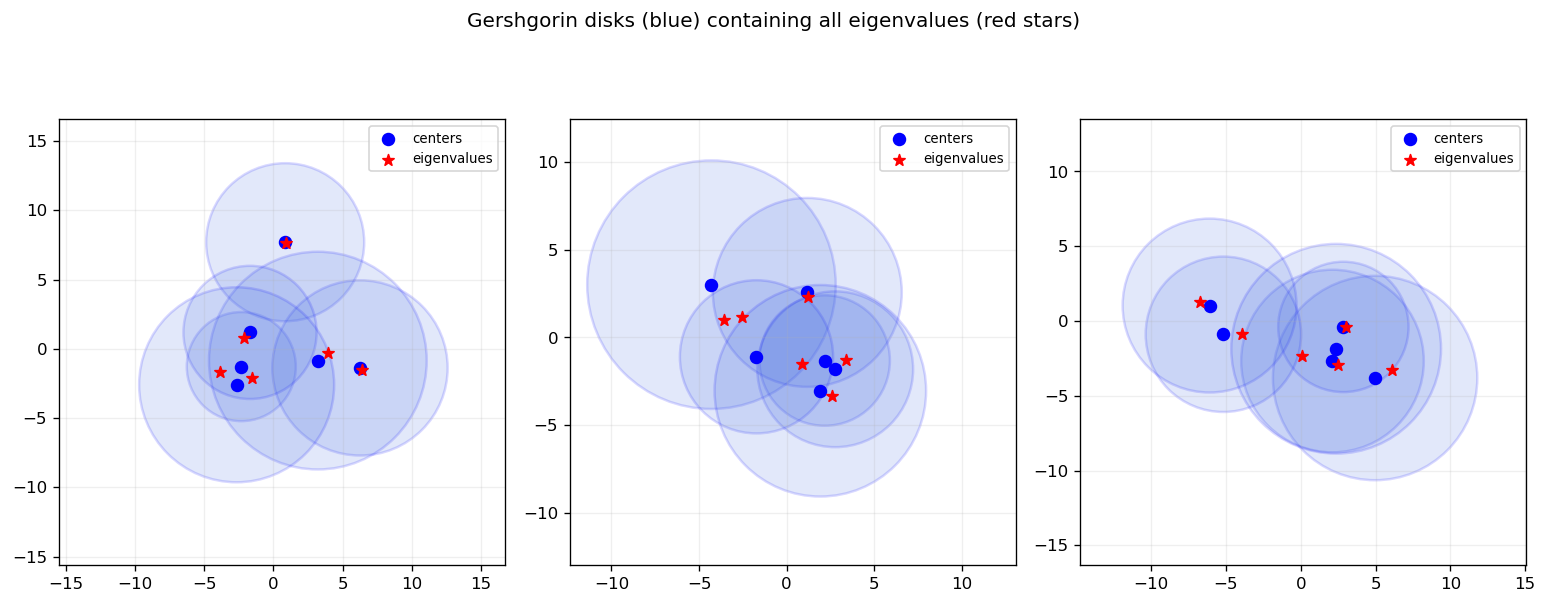

In [2]:
def gershgorin_data(A):
    """Compute Gershgorin centers and radii."""
    centers = np.diag(A)
    radii   = np.sum(np.abs(A), axis=1) - np.abs(centers)
    return centers, radii


rng = np.random.default_rng(7)

def make_matrix(n=6, diag_scale=5.0, seed=7):
    r = np.random.default_rng(seed)
    A = r.standard_normal((n, n)) + 1j * r.standard_normal((n, n))
    A += diag_scale * np.diag(r.standard_normal(n) + 1j * r.standard_normal(n))
    return A

matrices = [make_matrix(seed=s) for s in [7, 42, 99]]

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, A in zip(axes, matrices):
    centers, radii = gershgorin_data(A)
    eigvals = np.linalg.eigvals(A)

    # Draw disks
    for c, r in zip(centers, radii):
        disk = Circle((c.real, c.imag), r, fill=True,
                       facecolor='royalblue', edgecolor='blue',
                       alpha=0.15, linewidth=1.5)
        ax.add_patch(disk)

    ax.scatter(centers.real, centers.imag, s=50, c='blue', zorder=5, label='centers')
    ax.scatter(eigvals.real, eigvals.imag, s=50, c='red', marker='*',
               zorder=6, label='eigenvalues')

    # Axis limits
    all_pts = np.concatenate([centers, eigvals])
    margin = max(radii) + 1
    cx, cy = all_pts.real.mean(), all_pts.imag.mean()
    span = max(np.abs(all_pts.real - cx).max(), np.abs(all_pts.imag - cy).max()) + margin
    ax.set_xlim(cx - span, cx + span)
    ax.set_ylim(cy - span, cy + span)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle('Gershgorin disks (blue) containing all eigenvalues (red stars)', y=1.02)
plt.tight_layout()
plt.show()

## Tightness: when are the bounds sharp?

The Gershgorin bound is tightest when the matrix is **diagonally dominant** (small off-diagonal entries). As we scale up the off-diagonal part, the disks grow and the eigenvalues spread out but remain inside.

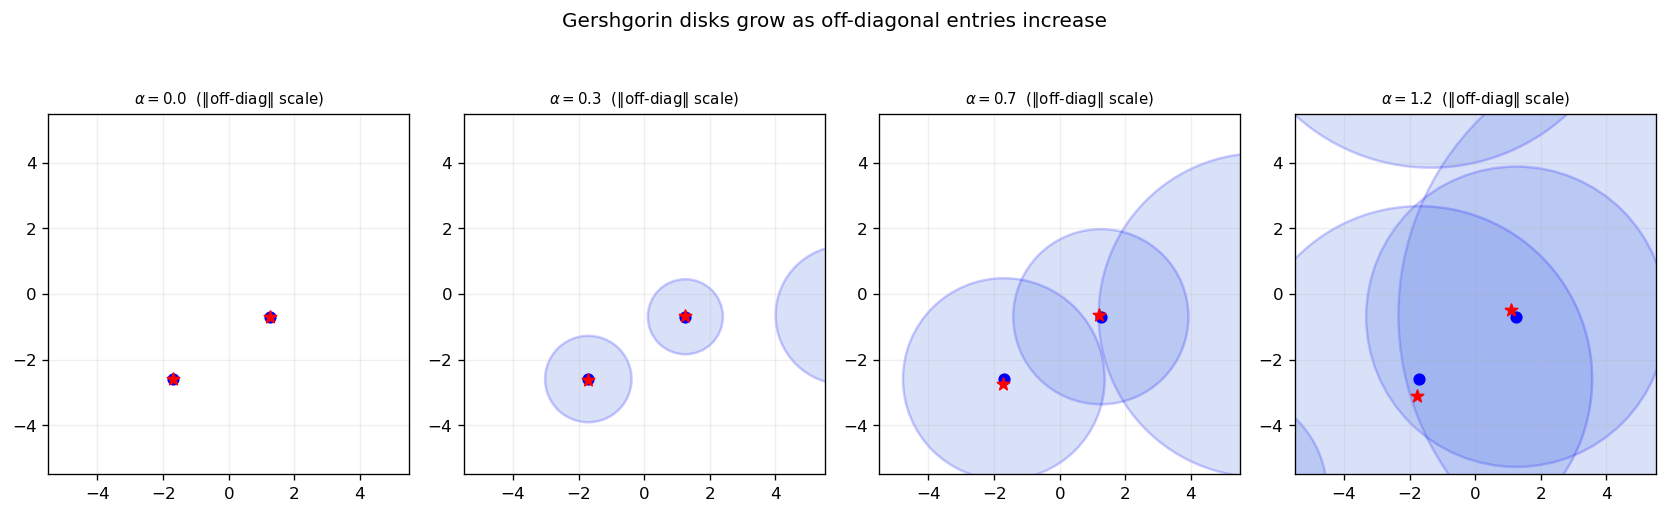

In [3]:
n = 5
rng2 = np.random.default_rng(3)
D_diag = np.diag(rng2.standard_normal(n) + 1j*rng2.standard_normal(n)) * 3
Off = rng2.standard_normal((n,n)) + 1j*rng2.standard_normal((n,n))
np.fill_diagonal(Off, 0)

alpha_vals = [0.0, 0.3, 0.7, 1.2]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, alpha in zip(axes, alpha_vals):
    A = D_diag + alpha * Off
    centers, radii = gershgorin_data(A)
    eigvals = np.linalg.eigvals(A)

    for c, r in zip(centers, radii):
        disk = Circle((c.real, c.imag), r, fill=True,
                       facecolor='royalblue', edgecolor='blue', alpha=0.2, lw=1.5)
        ax.add_patch(disk)
    ax.scatter(centers.real, centers.imag, s=40, c='blue', zorder=5)
    ax.scatter(eigvals.real, eigvals.imag, s=60, c='red', marker='*', zorder=6)
    ax.set_title(fr'$\alpha = {alpha}$  ($\|$off-diag$\|$ scale)', fontsize=9)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    span = 5.5
    ax.set_xlim(-span, span); ax.set_ylim(-span, span)

fig.suptitle('Gershgorin disks grow as off-diagonal entries increase', y=1.05)
plt.tight_layout()
plt.show()

## Column Gershgorin disks via $A^T$

Applying the theorem to $A^T$ gives **column Gershgorin disks** with column sums as radii. Since eigenvalues of $A$ and $A^T$ coincide, we get a second enclosure, and the intersection of the two unions is also valid. Often one is tighter than the other.

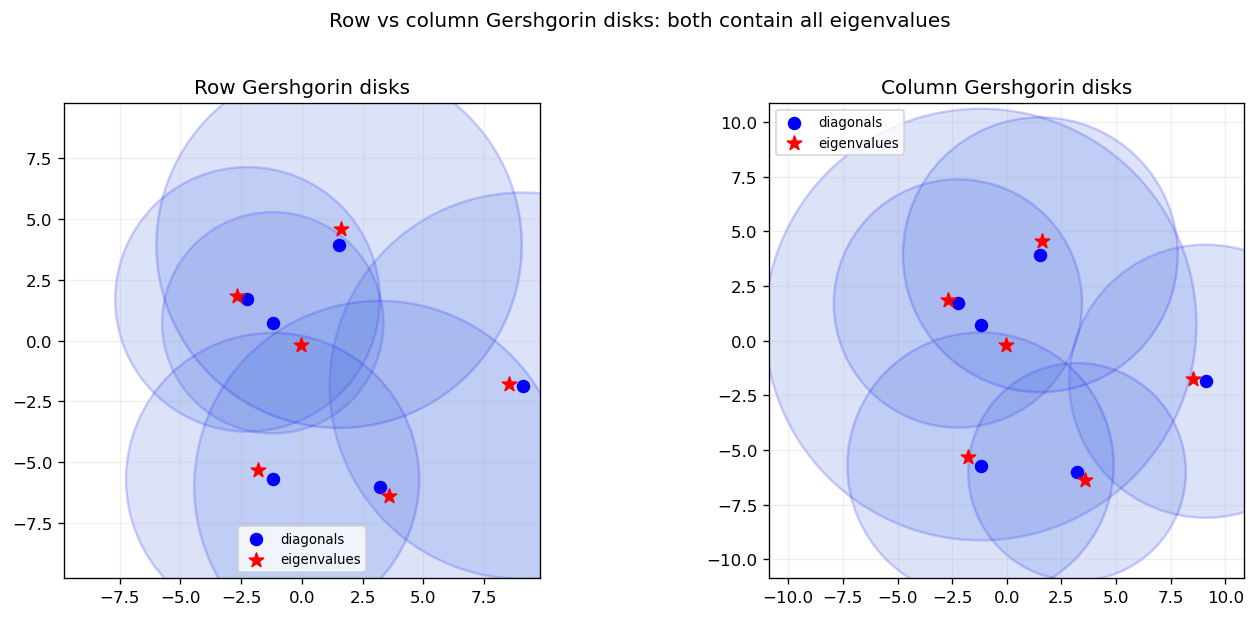

In [4]:
A_demo = make_matrix(n=6, diag_scale=4.0, seed=13)
row_centers, row_radii = gershgorin_data(A_demo)
col_centers, col_radii = gershgorin_data(A_demo.T)  # column version
eigvals_demo = np.linalg.eigvals(A_demo)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (c, r, title) in zip(axes, [
    (row_centers, row_radii, 'Row Gershgorin disks'),
    (col_centers, col_radii, 'Column Gershgorin disks'),
]):
    for ci, ri in zip(c, r):
        disk = Circle((ci.real, ci.imag), ri, fill=True,
                       facecolor='royalblue', edgecolor='blue', alpha=0.18, lw=1.5)
        ax.add_patch(disk)
    ax.scatter(c.real, c.imag, s=50, c='blue', zorder=5, label='diagonals')
    ax.scatter(eigvals_demo.real, eigvals_demo.imag, s=80, c='red',
               marker='*', zorder=6, label='eigenvalues')
    all_pts = np.concatenate([c, eigvals_demo])
    span = max(r.max()+1, np.abs(all_pts).max()+0.5)
    ax.set_xlim(-span, span); ax.set_ylim(-span, span)
    ax.set_aspect('equal'); ax.grid(alpha=0.2); ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle('Row vs column Gershgorin disks: both contain all eigenvalues', y=1.02)
plt.tight_layout()
plt.show()

## Interactive: interpolate between two matrices

We interpolate $A(t) = (1-t) A_0 + t A_1$ between two random matrices and watch the eigenvalues track continuously inside the Gershgorin disks.

In [5]:
A0_int = make_matrix(n=6, seed=5)
A1_int = make_matrix(n=6, seed=17)

def show_interp(t=0.0):
    A = (1-t)*A0_int + t*A1_int
    centers, radii = gershgorin_data(A)
    eigvals = np.linalg.eigvals(A)
    fig, ax = plt.subplots(figsize=(6, 6))
    for c, r in zip(centers, radii):
        disk = Circle((c.real, c.imag), r, fill=True,
                       facecolor='royalblue', edgecolor='blue', alpha=0.2, lw=1.5)
        ax.add_patch(disk)
    ax.scatter(centers.real, centers.imag, s=50, c='blue', zorder=5)
    ax.scatter(eigvals.real, eigvals.imag, s=80, c='red', marker='*', zorder=6)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    ax.set_title(f'$A(t={t:.2f}) = (1-t)A_0 + t A_1$')
    span = 9
    ax.set_xlim(-span, span); ax.set_ylim(-span, span)
    plt.tight_layout(); plt.show()

interact(show_interp,
         t=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description='$t$'));

interactive(children=(FloatSlider(value=0.0, description='$t$', max=1.0, step=0.02), Output()), _dom_classes=(…

## Bibliographical resources

- Gershgorin, S. (1931). Über die Abgrenzung der Eigenwerte einer Matrix. *Izvestiya Akademii Nauk SSSR, Ser. Fiz.-Mat.*, 7, 749–754.
- Varga, R. S. (2004). *Gershgorin and His Circles*. Springer.
- Horn, R. A. and Johnson, C. R. (2013). *Matrix Analysis* (2nd ed.). Cambridge University Press. Chapter 6.
- Brualdi, R. A. and Mellendorf, S. (1994). Regions in the complex plane containing the eigenvalues of a matrix. *The American Mathematical Monthly*, 101(10), 975–985.
- Trefethen, L. N. and Bau, D. (1997). *Numerical Linear Algebra*. SIAM.